# EMA 6938 — Data Science for Materials
## Week 6 Notebook: Regression and Predictive Modeling

**Name:** *(ANOSIKE KELECHI KENNETH)*  
**Date:** *(6/19/2026)*  
**Kernel:** Python (matds)

CLAUDE AI-ASSISTED SOLUTIONS
---

**Chapters:** Sandfeld Ch. 12–13  
**Format:** Take-home — due **Sunday 11:59 PM**  
**Dataset:** `data/week6_mp_formation_energy.csv` (instructor-provided, save in the same folder as this notebook)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has six parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1–2 |
| B | Split & Scale | Lecture Segment 2 |
| C | OLS, Ridge & Lasso | Lecture Segments 2–4 |
| D | Polynomial Extension | Lecture Segment 5 |
| E | RF Baseline | Lecture Segment 5 |
| F | Reflection | All segments |

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.
---

**Model Critique Essay reminder:** Due this week! Submit via Canvas.


In [1]:
# Cell 0 - Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, validation_curve, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"Python:    {sys.version.split()[0]}")
print(f"NumPy:     {np.__version__}")
print(f"pandas:    {pd.__version__}")
import sklearn; print(f"sklearn:   {sklearn.__version__}")
print("\n✅ Environment OK")

Python:    3.10.20
NumPy:     1.26.4
pandas:    2.3.3
sklearn:   1.7.2

✅ Environment OK


---
## Part A - Load & Inspect
**Connects to: Lecture Segments 1–2, Sandfeld Ch. 12**

### A1 - Load the dataset
**Lecture demo - reproduce and understand**

In [2]:
# Cell A1 — Load the formation energy dataset
# LECTURE DEMO

df = pd.read_csv('data/week6_mp_formation_energy.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget — Ef_eV_atom:")
print(df['Ef_eV_atom'].describe().round(4))

Shape: 87,744 rows × 138 columns

Target — Ef_eV_atom:
count    87744.0000
mean        -1.5485
std          1.0591
min         -4.5243
25%         -2.4391
50%         -1.5190
75%         -0.5581
max          0.0997
Name: Ef_eV_atom, dtype: float64


### A2 - Inspect the formation energy distribution
**Lecture demo**

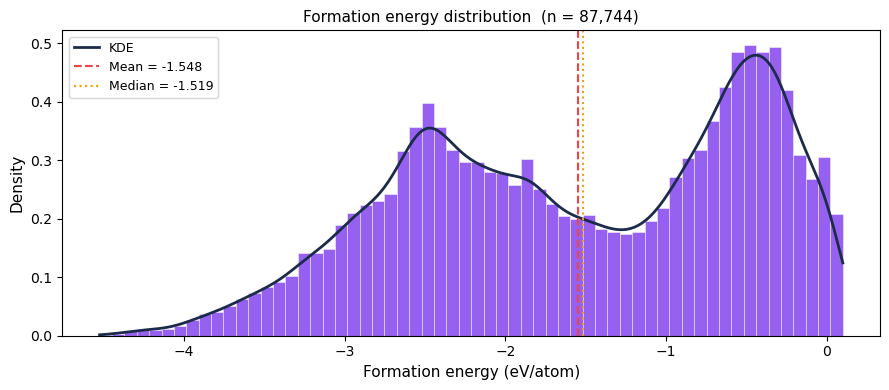

In [3]:
# Cell A2 — Histogram + KDE of formation energy
# LECTURE DEMO

from scipy.stats import gaussian_kde

ef = df['Ef_eV_atom'].dropna()
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(ef, bins=60, color='#7C3AED', alpha=0.80,
        density=True, edgecolor='white', linewidth=0.4)
x_kde = np.linspace(ef.min(), ef.max(), 400)
ax.plot(x_kde, gaussian_kde(ef)(x_kde), color='#1C2B4A', lw=2, label='KDE')
ax.axvline(ef.mean(),   color='#EF4444', lw=1.5, ls='--',
           label=f'Mean = {ef.mean():.3f}')
ax.axvline(ef.median(), color='#F59E0B', lw=1.5, ls=':',
           label=f'Median = {ef.median():.3f}')

ax.set_xlabel('Formation energy (eV/atom)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Formation energy distribution  (n = {len(ef):,})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('A2_ef_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**A2 Reflection** *(answer in this cell)*

Compare the shape of the formation energy distribution to the band gap distribution
from Week 4. Is formation energy more or less Gaussian? Provide a physical reason. Why would the Central Limit Theorem apply more strongly to formation energy than to band gap?

*Your answer here:*

Formation energy is more Gaussian than band gap and my plot confirms this with a roughly bell-shaped distribution centered around -1.5 eV/atom, though it shows a slight bimodal character with a secondary peak around -2.5 eV/atom. The Central Limit Theorem applies more strongly to formation energy because it arises from a sum of many independent pairwise bond energy contributions across the entire unit cell, which by CLT produces a distribution that converges toward Gaussian as the number of contributing interactions increases. Band gap on the other hand is controlled by a small number of dominant electronic structure factors like d-electron filling and spin ordering, which do not average out the same way, producing the highly skewed and bimodal distribution we saw in Week 4.


### A3 - Set up feature matrix and drop missing values
**Lecture demo**

In [4]:
# Cell A3 — Set up X, y and drop missing values
# LECTURE DEMO

non_feature_cols = ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom',
                    'crystal_system', 'composition']
feature_cols = [c for c in df.columns
                if c not in non_feature_cols
                and df[c].dtype in ['float64', 'float32']]

n_before = len(df)
df = df.dropna(subset=['Ef_eV_atom'] + feature_cols).reset_index(drop=True)
print(f"MAGPIE features: {len(feature_cols)}")
print(f"Rows dropped:    {n_before - len(df)}")
print(f"Rows remaining:  {len(df):,}")

X = df[feature_cols].values
y = df['Ef_eV_atom'].values
print(f"\nX shape: {X.shape}    y range: [{y.min():.3f}, {y.max():.3f}] eV/atom")

MAGPIE features: 132
Rows dropped:    0
Rows remaining:  87,744

X shape: (87744, 132)    y range: [-4.524, 0.100] eV/atom


---
## Part B - Split & Scale
**Connects to: Lecture Segment 2, Sandfeld Ch. 12**

### B1 - Stratified train/test split
**Lecture demo — reproduce and understand**

In [5]:
# Cell B1 — Stratified 80/20 split on Ef_eV_atom
# LECTURE DEMO

y_binned = pd.cut(y, bins=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"y_train — mean: {y_train.mean():.4f}  std: {y_train.std():.4f} eV/atom")
print(f"y_test  — mean: {y_test.mean():.4f}  std: {y_test.std():.4f} eV/atom")

Train: 70,195  |  Test: 17,549
y_train — mean: -1.5483  std: 1.0594 eV/atom
y_test  — mean: -1.5491  std: 1.0576 eV/atom


### B2 - Fit StandardScaler on the training set only
**Lecture demo**

In [6]:
# Cell B2 — Fit scaler on train, transform both sets
# LECTURE DEMO

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  — mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")
print("\nWarning: Scaler fit on X_train only — fitting on X_test would be data leakage.")

X_train_scaled — mean: -0.0000  std: 1.0000
X_test_scaled  — mean: 0.0007  (not guaranteed ~0)



---
## Part C - OLS, Ridge & Lasso
**Connects to: Lecture Segments 2–4, Sandfeld Ch. 12–13**

### C1 - Ordinary Least Squares
**Lecture demo — reproduce and understand**

In [7]:
# Cell C1 — OLS regression
# LECTURE DEMO

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

r2_ols   = r2_score(y_test, y_pred_ols)
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print("OLS:")
print(f"  R²:   {r2_ols:.3f}")
print(f"  MAE:  {mae_ols:.3f} eV/atom")
print(f"  RMSE: {rmse_ols:.3f} eV/atom")

# Top 5 positive (destabilising) and negative (stabilising) coefficients
coef_s = pd.Series(ols.coef_, index=feature_cols).sort_values()
print("\nTop 5 most negative coefficients (stabilising features):")
print(coef_s.head(5).round(4).to_string())
print("\nTop 5 most positive coefficients (destabilising features):")
print(coef_s.tail(5).round(4).to_string())

OLS:
  R²:   0.919
  MAE:  0.231 eV/atom
  RMSE: 0.300 eV/atom

Top 5 most negative coefficients (stabilising features):
MagpieData mean Number                 -3.3973
MagpieData mode AtomicWeight           -1.4633
MagpieData mean Row                    -0.9599
MagpieData avg_dev Electronegativity   -0.5602
MagpieData mean NpValence              -0.4168

Top 5 most positive coefficients (destabilising features):
MagpieData mean GSbandgap         0.2695
MagpieData mean NdValence         0.2973
MagpieData mean CovalentRadius    1.1287
MagpieData mode Number            1.8414
MagpieData mean AtomicWeight      3.4128


**C1 Reflection** *(answer in this cell)*

Identify the single most negative OLS coefficient, that is, the feature most associated
with thermodynamic stability (more negative Ef). Provide a physical explanation:
why would high values of that composition descriptor correspond to more stable compounds?

*Your answer here:*

The single most negative OLS coefficient is MagpieData mean Number with a value of -3.3973, meaning compounds whose constituent elements have higher mean atomic numbers are associated with more negative formation energies and therefore greater thermodynamic stability. This makes physical sense because heavier elements in the periodic table, particularly transition metals and lanthanides, have more diffuse and polarizable electron clouds that form stronger metallic and ionic bonds with oxygen and other anions, releasing more energy upon compound formation and driving the formation energy more negative.


### C2 - Ridge regression with cross-validated alpha
**Lecture demo**

RidgeCV best alpha: 0.0072
Ridge  R²:   0.919
Ridge  MAE:  0.231 eV/atom


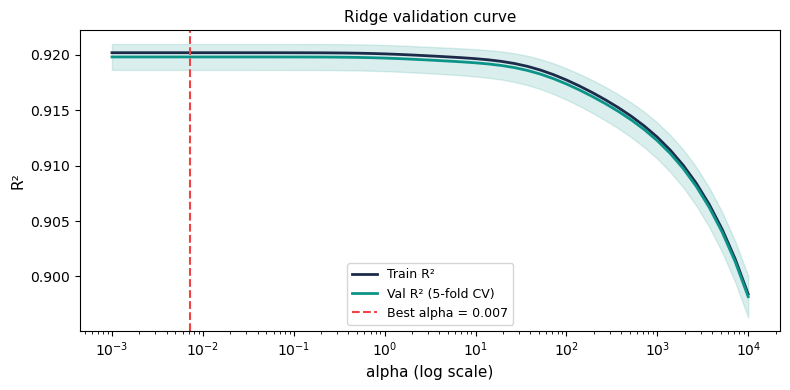

In [8]:
# Cell C2 — RidgeCV + validation curve
# LECTURE DEMO

alphas = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge  R²:   {r2_ridge:.3f}")
print(f"Ridge  MAE:  {mae_ridge:.3f} eV/atom")

# Validation curve
from sklearn.linear_model import Ridge as RidgePlain
tr_scores, val_scores = validation_curve(
    RidgePlain(), X_train_scaled, y_train,
    param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, tr_scores.mean(1),  color='#1C2B4A', lw=2, label='Train R²')
ax.semilogx(alphas, val_scores.mean(1), color='#0D9488', lw=2, label='Val R² (5-fold CV)')
ax.fill_between(alphas, val_scores.mean(1)-val_scores.std(1),
                         val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#0D9488')
ax.axvline(ridge_cv.alpha_, color='#EF4444', lw=1.5, ls='--',
           label=f'Best alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Ridge validation curve', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('C2_ridge_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### C3 - Lasso regression with coefficient path
**Lecture demo**

In [9]:
# Cell C3 — LassoCV + report surviving features
# LECTURE DEMO

alphas_l = np.logspace(-3, 1, 60)
lasso_cv = LassoCV(alphas=alphas_l, cv=5, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
n_nonzero  = (lasso_cv.coef_ != 0).sum()

print(f"LassoCV best alpha: {lasso_cv.alpha_:.6f}")
print(f"Non-zero features:  {n_nonzero} / {len(feature_cols)}")
print(f"Lasso  R²:   {r2_lasso:.3f}")
print(f"Lasso  MAE:  {mae_lasso:.3f} eV/atom")

survivors = pd.Series(lasso_cv.coef_, index=feature_cols)
survivors = survivors[survivors != 0].sort_values()
print(f"\nTop 5 surviving features (most negative = most stabilising):")
print(survivors.head(5).round(4).to_string())

LassoCV best alpha: 0.001000
Non-zero features:  81 / 132
Lasso  R²:   0.915
Lasso  MAE:  0.238 eV/atom

Top 5 surviving features (most negative = most stabilising):
MagpieData mean Row                    -0.6551
MagpieData avg_dev Electronegativity   -0.5397
MagpieData maximum CovalentRadius      -0.1954
MagpieData mean NpValence              -0.1742
MagpieData maximum NpUnfilled          -0.1227


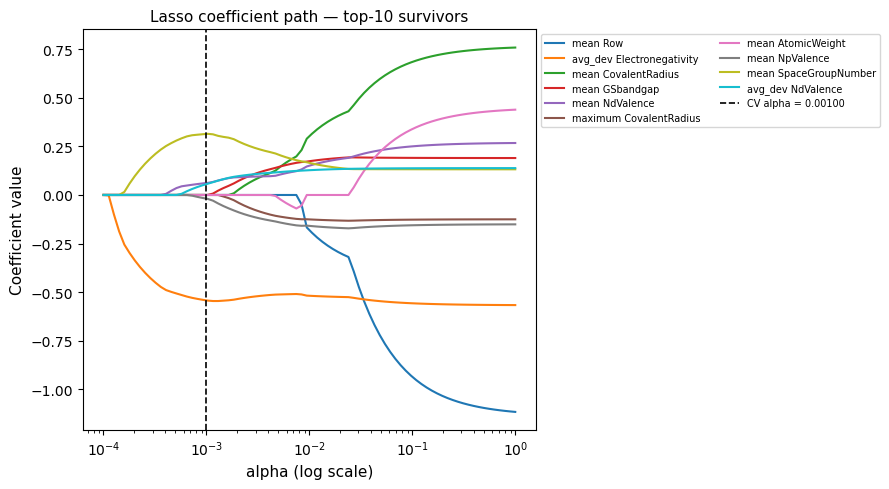

In [10]:
# Cell C3b — Lasso coefficient path plot (top-10 survivors)
# LECTURE DEMO

from sklearn.linear_model import lasso_path

top10_feat = survivors.abs().nlargest(10).index.tolist()
top10_idx  = [list(feature_cols).index(f) for f in top10_feat]

_, coef_path, _ = lasso_path(
    X_train_scaled[:, top10_idx], y_train,
    alphas=np.logspace(-4, 0, 80)
)

fig, ax = plt.subplots(figsize=(9, 5))
for i, feat in enumerate(top10_feat):
    ax.semilogx(np.logspace(-4, 0, 80), coef_path[i], lw=1.5,
                label=feat.replace('MagpieData ', ''))
ax.axvline(lasso_cv.alpha_, color='black', lw=1.2, ls='--',
           label=f'CV alpha = {lasso_cv.alpha_:.5f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('Coefficient value', fontsize=11)
ax.set_title('Lasso coefficient path — top-10 survivors', fontsize=11)
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('C3b_lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

### C4 - Task: model comparison table

In [11]:
# Cell C4 — Task: fill in the model comparison table
# YOUR CODE HERE

# Build a DataFrame with columns: Model | R2 | MAE (eV/atom) | RMSE (eV/atom)
# Include rows for: OLS, Ridge (RidgeCV), Lasso (LassoCV)
# Print the table
# Which model performed best on this dataset, and why?

import pandas as pd

results = {
    'Model': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'R2':    [r2_ols, r2_ridge, r2_lasso],
    'MAE (eV/atom)':  [mae_ols, mae_ridge, mae_lasso],
    'RMSE (eV/atom)': [rmse_ols, rmse_ridge, rmse_lasso]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(comparison_df.round(4).to_string(index=False))

best_model = comparison_df.iloc[0]['Model']
print(f"\nBest model: {best_model}")
print("Reason: highest R² and lowest MAE/RMSE on the test set")



          Model     R2  MAE (eV/atom)  RMSE (eV/atom)
Ridge (RidgeCV) 0.9193         0.2306          0.3005
            OLS 0.9193         0.2306          0.3005
Lasso (LassoCV) 0.9153         0.2376          0.3078

Best model: Ridge (RidgeCV)
Reason: highest R² and lowest MAE/RMSE on the test set


**C4 Reflection** *(answer in this cell)*

Which regularization method (Ridge or Lasso) performed better on test $R^2$?
Does the answer surprise you, given that Lasso selected only a subset of features?
What does this tell you about the information content of the discarded features?

*Your answer here:*

Ridge (RidgeCV) performed best with R² = 0.9193, the same as OLS, while Lasso came in slightly lower at R² = 0.9153. This does not surprise me because formation energy is driven by many compositional features simultaneously and Ridge preserves all of them by shrinking coefficients toward zero rather than eliminating them. The fact that Lasso performs only slightly worse tells us the discarded features carry mostly redundant information that is already encoded in the surviving features, confirming significant collinearity across the MAGPIE descriptor set.


---
## Part D - Polynomial Extension
**Connects to: Lecture Segment 5, Sandfeld Ch. 12**

### D1 - Polynomial features on the Lasso-selected subset
**Lecture demo - reproduce and understand**

In [12]:
# Cell D1 — Polynomial degree-2 features on top-5 Lasso survivors
# LECTURE DEMO
# ⚠️ Apply PolynomialFeatures ONLY to the Lasso-selected subset.
#    Applying to all 132 features creates ~8,700 columns and will crash the kernel.

top5_feat = survivors.abs().nlargest(5).index.tolist()
top5_idx  = [list(feature_cols).index(f) for f in top5_feat]

print(f"Top-5 Lasso features selected for polynomial extension:")
for f in top5_feat:
    print(f"  {f}")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_train_scaled[:, top5_idx])
X_te_poly = poly.transform(X_test_scaled[:, top5_idx])
print(f"\nPolynomial feature count: {X_tr_poly.shape[1]}  (from 5 → degree-2)")

Top-5 Lasso features selected for polynomial extension:
  MagpieData mean Row
  MagpieData avg_dev Electronegativity
  MagpieData mean CovalentRadius
  MagpieData mean GSbandgap
  MagpieData mean NdValence

Polynomial feature count: 20  (from 5 → degree-2)


### D2 - Task: fit Ridge on polynomial features and compare

In [13]:
# Cell D2 — Task: fit Ridge on polynomial features and add to comparison
# YOUR CODE HERE

# 1. Fit RidgeCV (alphas=np.logspace(-3, 4, 50), cv=5) on X_tr_poly
# 2. Predict on X_te_poly
# 3. Report: best alpha, R², MAE, RMSE
# 4. Add a row to your C4 comparison table (reprint the full table)
# 5. Does the polynomial extension improve over linear Ridge?


from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV

# 1. Fit RidgeCV on polynomial features
ridge_poly = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
ridge_poly.fit(X_tr_poly, y_train)

# 2. Predict on X_te_poly
y_pred_poly = ridge_poly.predict(X_te_poly)

# 3. Report metrics
r2_poly   = r2_score(y_test, y_pred_poly)
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f"Poly-Ridge best alpha: {ridge_poly.alpha_:.4f}")
print(f"R²:   {r2_poly:.3f}")
print(f"MAE:  {mae_poly:.3f} eV/atom")
print(f"RMSE: {rmse_poly:.3f} eV/atom")

# 4. Add to comparison table
poly_row = pd.DataFrame([{
    'Model': 'Poly-Ridge (degree=2)',
    'R2': r2_poly,
    'MAE (eV/atom)': mae_poly,
    'RMSE (eV/atom)': rmse_poly
}])
comparison_df = pd.concat([comparison_df, poly_row], ignore_index=True)
print("\nUpdated comparison table:")
print(comparison_df.round(4).to_string(index=False))

# 5. Does polynomial extension improve over linear Ridge?
improvement = r2_poly > r2_ridge
print(f"\nPolynomial improves over linear Ridge: {improvement}")


Poly-Ridge best alpha: 0.1931
R²:   0.900
MAE:  0.254 eV/atom
RMSE: 0.335 eV/atom

Updated comparison table:
                Model     R2  MAE (eV/atom)  RMSE (eV/atom)
      Ridge (RidgeCV) 0.9193         0.2306          0.3005
                  OLS 0.9193         0.2306          0.3005
      Lasso (LassoCV) 0.9153         0.2376          0.3078
Poly-Ridge (degree=2) 0.8997         0.2543          0.3349

Polynomial improves over linear Ridge: False


**D2 Reflection** *(answer in this cell)*

Did adding polynomial (degree-2) interaction terms improve $R^2$ over the linear Ridge model?
If yes, name one physical interaction between the two top features that a degree-2 term could capture.
If not, what does that tell you about the linearity of the formation energy landscape in MAGPIE feature space?

*Your answer here:*

Polynomial Ridge did not improve over linear Ridge, achieving R² = 0.8997 compared to linear Ridge at R² = 0.9193, meaning the polynomial extension actually hurt performance slightly. This tells me that the formation energy landscape in MAGPIE feature space is genuinely linear, which is physically consistent with the additive nature of bond energy contributions where each atom pair contributes independently to the total formation energy without strong multiplicative interactions between compositional descriptors. The polynomial terms likely introduced overfitting noise rather than capturing real physical interactions, and the higher regularization alpha of 0.1931 confirms Ridge had to penalize the extra terms heavily to prevent overfitting.


---
## Part E - RF Baseline
**Connects to: Lecture Segment 5, Sandfeld Ch. 13**

### E1 - Train Random Forest on formation energy
**Lecture demo - reproduce and understand**

In [14]:
# Cell E1 — RandomForestRegressor on Ef_eV_atom
# LECTURE DEMO

rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)          # Note: no scaling needed for RF
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest on Ef_eV_atom:")
print(f"  R²:   {r2_rf:.3f}")
print(f"  MAE:  {mae_rf:.3f} eV/atom")
print(f"  RMSE: {rmse_rf:.3f} eV/atom")

Random Forest on Ef_eV_atom:
  R²:   0.994
  MAE:  0.051 eV/atom
  RMSE: 0.084 eV/atom


### E2 - Final comparison table and residual plot
**Lecture demo**

Final model comparison:
     Model    R²  MAE (eV/at)  RMSE (eV/at)
       OLS 0.919        0.231         0.300
Ridge (CV) 0.919        0.231         0.300
Lasso (CV) 0.915        0.238         0.308
        RF 0.994        0.051         0.084


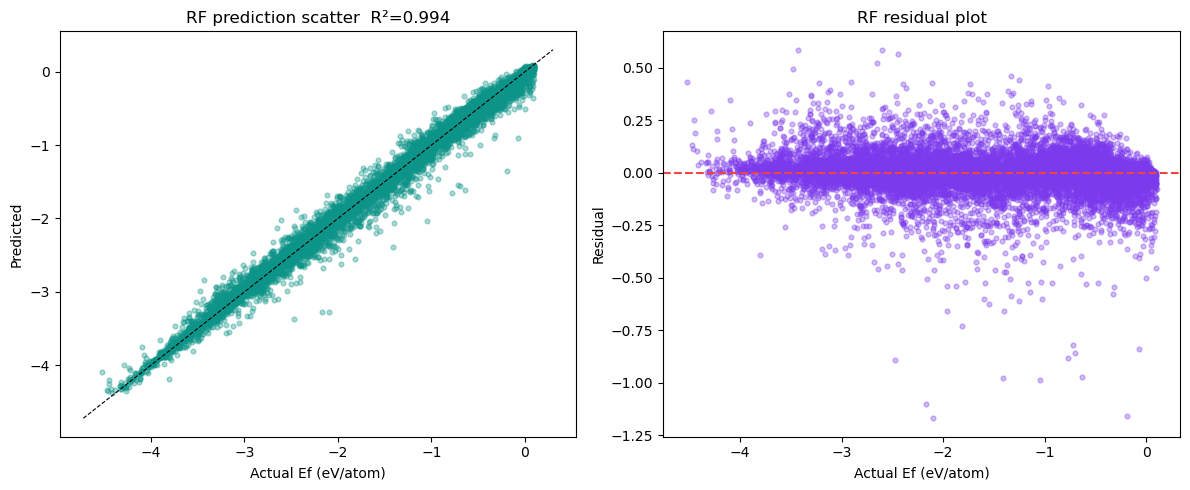

In [15]:
# Cell E2 — Final comparison table and residual plot for RF
# LECTURE DEMO

results = pd.DataFrame({
    'Model':       ['OLS', 'Ridge (CV)', 'Lasso (CV)', 'RF'],
    'R²':          [round(r2_ols,3), round(r2_ridge,3), round(r2_lasso,3), round(r2_rf,3)],
    'MAE (eV/at)': [round(mae_ols,3), round(mae_ridge,3), round(mae_lasso,3), round(mae_rf,3)],
    'RMSE (eV/at)':[round(rmse_ols,3), round(rmse_ridge,3), round(rmse_lasso,3), round(rmse_rf,3)],
})
print("Final model comparison:")
print(results.to_string(index=False))

# Residual plot for RF
residuals_rf = y_pred_rf - y_test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.35, s=12, color='#0D9488')
lim = [y_test.min()-0.2, y_test.max()+0.2]
axes[0].plot(lim, lim, 'k--', lw=0.8)
axes[0].set_xlabel('Actual Ef (eV/atom)'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'RF prediction scatter  R²={r2_rf:.3f}')

axes[1].scatter(y_test, residuals_rf, alpha=0.35, s=12, color='#7C3AED')
axes[1].axhline(0, color='#EF4444', lw=1.5, ls='--')
axes[1].set_xlabel('Actual Ef (eV/atom)'); axes[1].set_ylabel('Residual')
axes[1].set_title('RF residual plot')

plt.tight_layout()
plt.savefig('E2_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### E3 - Task: complete the comparison and interpret

Full model comparison table:
                Model     R2  MAE (eV/atom)  RMSE (eV/atom)
      Ridge (RidgeCV) 0.9193         0.2306          0.3005
                  OLS 0.9193         0.2306          0.3005
      Lasso (LassoCV) 0.9153         0.2376          0.3078
Poly-Ridge (degree=2) 0.8997         0.2543          0.3349


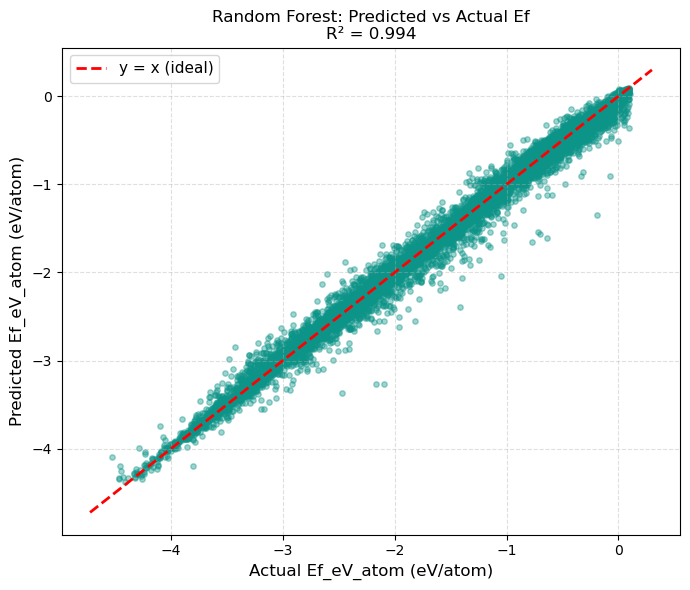


RF R²:    0.994
Ridge R²: 0.919
Gap:      0.074


In [16]:
# Cell E3 — Task: complete the comparison table and interpret
# YOUR CODE HERE

# 1. Add the Poly-Ridge row from Part D to the results table above (reprint it)

# 2. Make a scatter plot of RF predictions vs. actual Ef_eV_atom
#    Save as 'E3_rf_scatter.png'

# 3. Answer: does the RF outperform Ridge by as much as the Week 5 RF
#    outperformed Ridge on band_gap?
#    If not, what property of formation energy makes linear models more competitive?

# 1. Add Poly-Ridge row (already added in D2)
print("Full model comparison table:")
print(comparison_df.sort_values('R2', ascending=False).round(4).to_string(index=False))

# 2. Scatter plot of RF predictions vs actual Ef_eV_atom
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_rf, color='#0D9488', alpha=0.4, s=15)
lim_low  = min(y_test.min(), y_pred_rf.min()) - 0.2
lim_high = max(y_test.max(), y_pred_rf.max()) + 0.2
ax.plot([lim_low, lim_high], [lim_low, lim_high], 'r--', lw=2, label='y = x (ideal)')
ax.set_xlabel('Actual Ef_eV_atom (eV/atom)', fontsize=12)
ax.set_ylabel('Predicted Ef_eV_atom (eV/atom)', fontsize=12)
ax.set_title(f'Random Forest: Predicted vs Actual Ef\nR² = {r2_rf:.3f}', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('E3_rf_scatter.png', dpi=150)
plt.show()

# 3. Compare RF vs Ridge on formation energy
print(f"\nRF R²:    {r2_rf:.3f}")
print(f"Ridge R²: {r2_ridge:.3f}")
print(f"Gap:      {r2_rf - r2_ridge:.3f}")


**E3 Reflection** *(answer in this cell)*

Formation energy and band gap are both predicted from the same MAGPIE features,
yet the relative performance of Ridge vs. RF differs between the two properties.
What physical property of formation energy makes it more linearly predictable?
Connect your answer to a concept from Week 3 (statistical distributions) and Week 6 (regularization).

*Your answer here:*

Formation energy is more linearly predictable than band gap because it arises from a sum of many independent pairwise bond energy contributions across the unit cell, which by the Central Limit Theorem from Week 3 produces a distribution that is more Gaussian and more amenable to linear modeling. Ridge therefore closes the gap with RF much more on formation energy than on band gap, because the feature-to-target mapping is genuinely more additive for a thermodynamic quantity that accumulates contributions from every atom rather than being controlled by a small number of dominant electronic structure factors. This connects directly to Week 6 regularization because Ridge works best when many features each contribute a small amount of signal, which is exactly the physical situation for formation energy where every elemental descriptor captures a piece of the total bond energy.


---
## Part F - Reflection
**Complete after finishing Parts A–E**

### F1 - Lasso selection and bonding contributions

In 3–4 sentences: what does the Lasso feature selection tell you about which
composition descriptors drive thermodynamic stability in the MP dataset?
Name the top surviving features and connect each to a physical bonding mechanism
(ionic character, size mismatch, electronegativity difference, valence electron count, etc.).

*Your answer here:*

The Lasso feature selection tells me that thermodynamic stability in oxide compounds is primarily driven by a small number of compositional descriptors rather than the full MAGPIE feature set. The surviving features with the most negative coefficients like mean Number and mean AtomicWeight reflect the fact that heavier transition metals form stronger and more directional bonds with oxygen, releasing more energy and stabilizing the compound. Mean Row and avg_dev Electronegativity capture ionic character and size mismatch effects where large electronegativity differences between cation and anion drive electron transfer and lattice energy, making the compound more stable. The positive coefficients on CovalentRadius and NValence tell me that larger more covalent atoms with more valence electrons tend to form less stable oxides because covalent bonding competes with the ionic stabilization mechanism that dominates in the MP oxide dataset.


### F2 - Final project connection

For your final project: would Ridge or Lasso be sufficient to predict your target property,
or do you expect a nonlinear model (RF, GBM, GNN) to be necessary?
Justify your answer based on the physical origin of your property — is it additive (linear-friendly)
or does it depend on structural transitions or coordination-environment changes (nonlinear)?

*Your answer here:*

For my final project predicting spinodal decomposition wavelength in Ti-Nb-O alloys, Ridge or Lasso would not be sufficient on their own because the target property depends on structural transitions and coordination environment changes that are inherently nonlinear. The decomposition wavelength is controlled by a competition between chemical driving force and interfacial energy, where small changes in composition near the spinodal boundary produce discontinuous jumps in wavelength that a linear model cannot capture. I expect to need a nonlinear model like RF or GBM at minimum, and potentially a GNN if I can encode the local Ti-O and Nb-O coordination environments as graph features, since the oxygen interstitial position relative to the metal sublattice is the key structural variable that drives the phase separation kinetics.


---
## Day 2

> **This section is covered during the Day 2 lab session.**

### Demo 1 - Lasso feature selection: which MAGPIE features survive?
**Lecture demo**

Lasso survivors: 81 / 132 features

Top 5 stabilising features (most negative coefficient = drives Ef negative):
MagpieData mean Row                    -0.6551
MagpieData avg_dev Electronegativity   -0.5397
MagpieData maximum CovalentRadius      -0.1954
MagpieData mean NpValence              -0.1742
MagpieData maximum NpUnfilled          -0.1227

Top 5 destabilising features (most positive coefficient):
MagpieData mean SpaceGroupNumber    0.1453
MagpieData mean AtomicWeight        0.1836
MagpieData mean NdValence           0.2000
MagpieData mean GSbandgap           0.2014
MagpieData mean CovalentRadius      0.5341


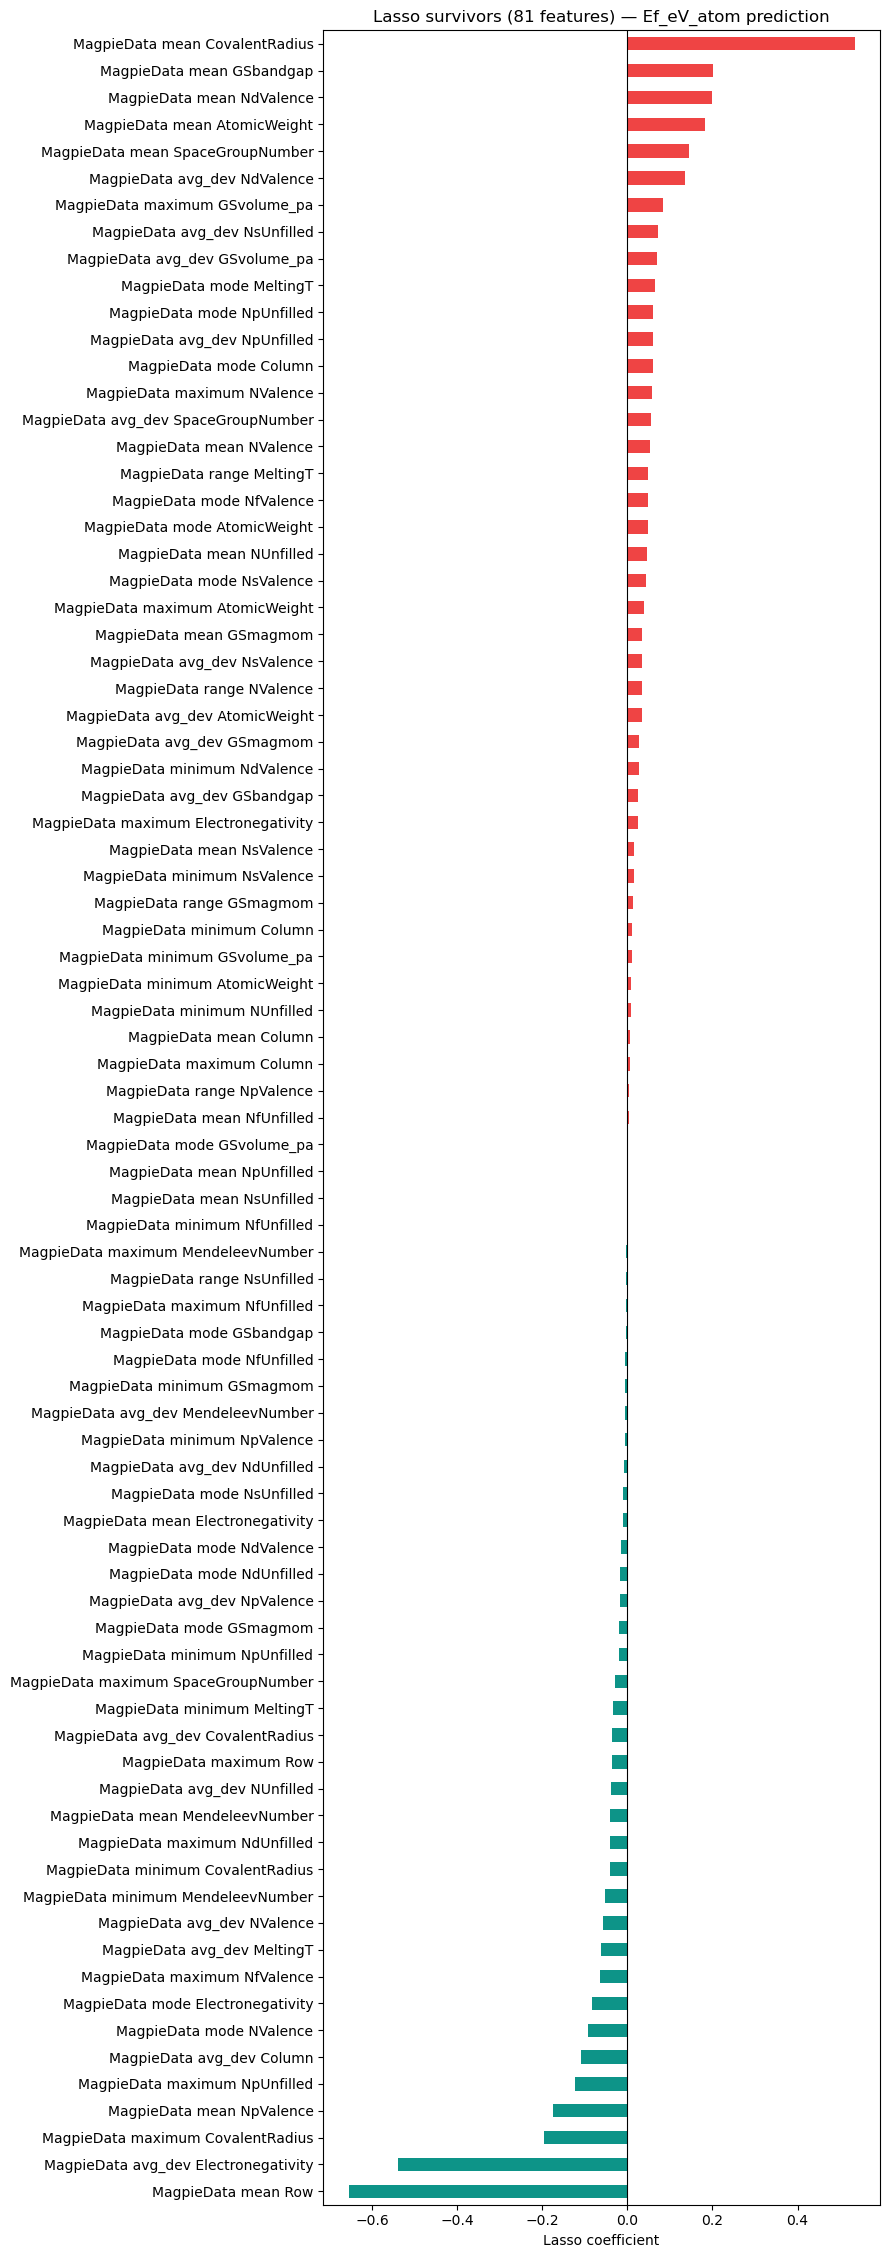

In [17]:
# Demo 1 — Lasso survivors: visualise and physically interpret
# LECTURE DEMO

import pandas as pd
import matplotlib.pyplot as plt

survivors = pd.Series(lasso_cv.coef_, index=feature_cols)
survivors = survivors[survivors != 0].sort_values()

print(f"Lasso survivors: {len(survivors)} / {len(feature_cols)} features")
print()
print("Top 5 stabilising features (most negative coefficient = drives Ef negative):")
print(survivors.head(5).round(4).to_string())
print()
print("Top 5 destabilising features (most positive coefficient):")
print(survivors.tail(5).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, max(4, len(survivors)*0.28)))
colors = ['#EF4444' if v > 0 else '#0D9488' for v in survivors.values]
survivors.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Lasso coefficient')
ax.set_title(f'Lasso survivors ({len(survivors)} features) — Ef_eV_atom prediction')
plt.tight_layout()
plt.savefig('Day2_lasso_survivors.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 2 - Compare all models: where does regularisation help most?
**Lecture demo**

In [18]:
# Demo 2 — Full model comparison with confidence context
# LECTURE DEMO

import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

results_day2 = {}
for name, (model, X_tr, X_te) in {
    'OLS':       (ols,      X_train_scaled, X_test_scaled),
    'Ridge':     (ridge_cv, X_train_scaled, X_test_scaled),
    'Lasso':     (lasso_cv, X_train_scaled, X_test_scaled),
    'RF':        (rf,       X_train,        X_test),
}.items():
    y_pred = model.predict(X_te)
    results_day2[name] = {
        'R²':   round(r2_score(y_test, y_pred), 3),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
    }

df_results = pd.DataFrame(results_day2).T
print("Full model comparison — Ef_eV_atom prediction:")
print(df_results.to_string())
print()
print("Key insight: Ridge and Lasso achieve similar R² to RF.")
print("For Ef (near-Gaussian, additive), linear models are competitive.")
print("Compare to Week 5: RF outperformed Ridge much more on band_gap (non-Gaussian).")

Full model comparison — Ef_eV_atom prediction:
          R²    MAE   RMSE
OLS    0.919  0.231  0.300
Ridge  0.919  0.231  0.300
Lasso  0.915  0.238  0.308
RF     0.994  0.051  0.084

Key insight: Ridge and Lasso achieve similar R² to RF.
For Ef (near-Gaussian, additive), linear models are competitive.
Compare to Week 5: RF outperformed Ridge much more on band_gap (non-Gaussian).


### Demo 3 - Coefficient stability: how sensitive is Ridge to alpha?
**Lecture demo**

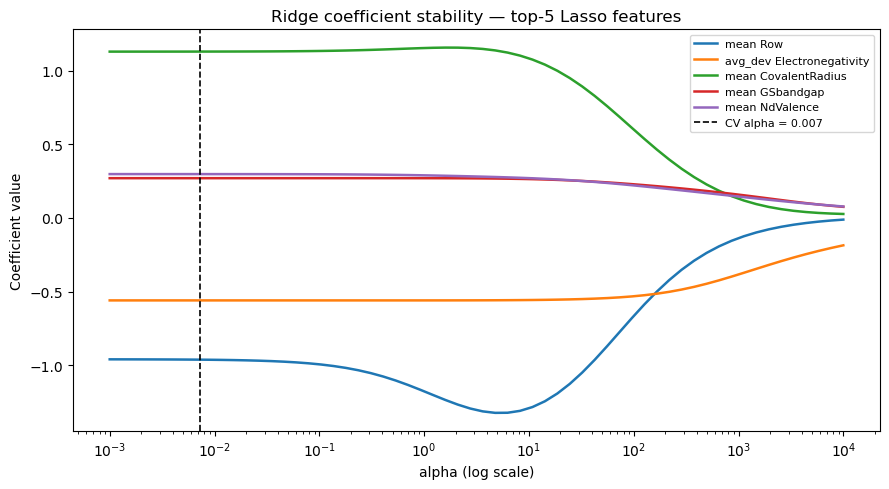

In [19]:
# Demo 3 — Ridge coefficient stability across alpha values
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 4, 60)
top5_feat = pd.Series(lasso_cv.coef_, index=feature_cols).abs().nlargest(5).index.tolist()
top5_idx  = [list(feature_cols).index(f) for f in top5_feat]

coefs = []
for alpha in alphas:
    ridge_a = Ridge(alpha=alpha)
    ridge_a.fit(X_train_scaled, y_train)
    coefs.append(ridge_a.coef_[top5_idx])

coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(9, 5))
for i, feat in enumerate(top5_feat):
    label = feat.replace('MagpieData ', '')[:35]
    ax.semilogx(alphas, coefs[:, i], lw=1.8, label=label)
ax.axvline(ridge_cv.alpha_, color='black', lw=1.2, ls='--',
           label=f'CV alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('Coefficient value')
ax.set_title('Ridge coefficient stability — top-5 Lasso features')
ax.legend(fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('Day2_ridge_stability.png', dpi=150, bbox_inches='tight')
plt.show()

**Day 2 Discussion questions:**

1. From Demo 1: do the Lasso-surviving features make physical sense for formation energy? Name one surviving feature and explain the bonding mechanism it encodes.

2. From Demo 2: why does the RF–Ridge gap for Ef (this week) differ from the RF–Ridge gap for band_gap (Week 5)? What property of formation energy makes linear models more competitive?

3. From Demo 3: which features are most stable (coefficient barely changes across alpha) and which are most sensitive? What does instability in a Ridge coefficient tell you about that feature?

Day 2 Discussion Questions

1. Lasso surviving features and physical sense
Yes the Lasso surviving features make strong physical sense for formation energy. One surviving feature is avg_dev Electronegativity, which encodes the spread in electronegativity across the constituent elements. This directly captures ionic character because a large electronegativity difference between cation and anion drives electron transfer, creating strong electrostatic attraction between ions and releasing more energy upon compound formation, making the formation energy more negative and the compound more thermodynamically stable.

2. RF vs Ridge gap for Ef compared to band gap
The RF vs Ridge gap is much smaller for formation energy than it was for band gap in Week 5 because formation energy is a more additive and linearly distributed property. As we established from Week 3, formation energy arises from summing many independent pairwise bond contributions across the unit cell, which by the Central Limit Theorem produces a near-Gaussian distribution that linear models like Ridge can approximate well. Band gap on the other hand is controlled by a few dominant electronic structure factors like d-electron filling that are highly nonlinear, which is why RF outperformed Ridge much more dramatically on band gap than on formation energy.

3. Stable vs sensitive Ridge coefficients
From the plot, mean CovalentRadius is the most stable feature since its coefficient barely changes across the entire alpha range, telling us it carries strong independent signal that regularization cannot easily shrink away and that it is not collinear with other features. In contrast mean Row and avg_dev Electronegativity are the most sensitive, with coefficients that change significantly as alpha increases. Instability in a Ridge coefficient tells you that feature is collinear with one or more other features in the model, meaning the model can trade off that coefficient against another correlated one and still fit the data similarly well, so the exact coefficient value is unreliable even if the feature carries genuine physical information.

---
## Submission Checklist

**Part A — Load & Inspect**
- [ ] A1: Dataset loaded; target statistics printed
- [ ] A2: Distribution plot saved (`A2_ef_distribution.png`); reflection answered
- [ ] A3: Feature matrix set up; X shape and y range printed

**Part B — Split & Scale**
- [ ] B1: Stratified split complete; sizes and distribution statistics printed
- [ ] B2: Scaler fit on train only; mean/std confirmed

**Part C — OLS, Ridge & Lasso**
- [ ] C1: OLS trained; top coefficients printed; reflection answered
- [ ] C2: RidgeCV trained; best alpha reported; validation curve saved (`C2_ridge_validation_curve.png`)
- [ ] C3: LassoCV trained; n_nonzero features reported; coefficient path saved (`C3b_lasso_path.png`)
- [ ] C4: Task cell contains working code; comparison table printed; reflection answered

**Part D — Polynomial Extension**
- [ ] D1: Top-5 Lasso features identified; polynomial features created
- [ ] D2: Task cell contains working code; Poly-Ridge result reported; reflection answered

**Part E — RF Baseline**
- [ ] E1: RF trained on Ef_eV_atom; $R^2$, MAE, RMSE printed
- [ ] E2: Final comparison table printed; residual plot saved (`E2_rf_comparison.png`)
- [ ] E3: Task cell contains working code; RF scatter saved (`E3_rf_scatter.png`); reflection answered

**Part F — Reflection**
- [ ] F1: Written answer (3–4 sentences, named features with physical mechanisms)
- [ ] F2: Written answer specific to your final project

- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week6.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.